# JusticeCast — Phase 2 EDA

Exploratory pass on the joined `(case, Justice)` table from Phase 1.
Inputs:

- `data/processed/justice_case_rows.parquet` — pre-cleanup, what came out of `build_dataset.py`
- `data/processed/modeling_table.parquet` — post-cleanup, what feeds Phase 3 modeling

**Goal:** characterize the data, motivate the inclusion/exclusion decisions, and surface the storytelling angles for the pitch deck (Phase 7).

Reproducibility: `Restart & Run All` from the project venv (`.venv/bin/jupyter lab`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make project root importable when the notebook runs from notebooks/.
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

raw = pd.read_parquet(ROOT / 'data/processed/justice_case_rows.parquet')
model = pd.read_parquet(ROOT / 'data/processed/modeling_table.parquet')
labeled = raw[raw['voted_petitioner'].notna()].copy()

print(f'Raw parquet:        {len(raw):>6,} rows  ({raw["caseId"].nunique():,} cases)')
print(f'Labeled rows:       {len(labeled):>6,} rows  ({labeled["caseId"].nunique():,} cases)')
print(f'Modeling table:     {len(model):>6,} rows  ({model["caseId"].nunique():,} cases)')
print(f'Window:             {int(model["term"].min())}-{int(model["term"].max())} (OT terms)')

Raw parquet:        10,308 rows  (1,309 cases)
Labeled rows:       10,137 rows  (1,295 cases)
Modeling table:     10,039 rows  (1,293 cases)
Window:             2005-2024 (OT terms)


## 1. Vote-label distribution

The binary label is `voted_petitioner` (1 if the Justice voted with the petitioner, 0 otherwise). Class imbalance is real — ~62% petitioner-win — and we treat it explicitly with `class_weight='balanced'` per Non-Negotiable #6.

Overall label balance (labeled rows):
  0 (against petitioner):  37.7%
  1 (with petitioner   ):  62.3%

Majority-class baseline: 62.3%


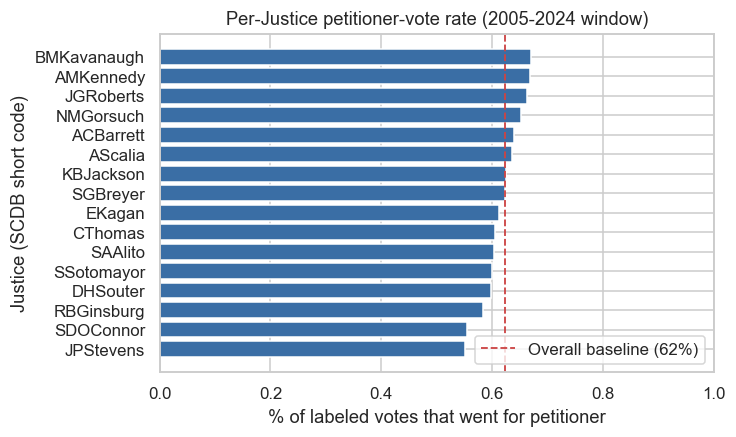

In [2]:
overall = labeled['voted_petitioner'].value_counts(normalize=True).sort_index()
print('Overall label balance (labeled rows):')
for k, v in overall.items():
    label = 'with petitioner' if k == 1 else 'against petitioner'
    print(f'  {int(k)} ({label:18s}):  {v:.1%}')
print(f'\nMajority-class baseline: {overall.max():.1%}')

fig, ax = plt.subplots(figsize=(6.5, 4))
by_just = (labeled.groupby('justiceName')['voted_petitioner']
           .agg(['mean', 'size'])
           .rename(columns={'mean': 'pct_with_petitioner', 'size': 'n'})
           .sort_values('pct_with_petitioner'))
ax.barh(by_just.index, by_just['pct_with_petitioner'], color='#3a6ea5')
ax.axvline(overall.max(), color='#c44', linestyle='--', linewidth=1.2,
           label=f'Overall baseline ({overall.max():.0%})')
ax.set_xlabel('% of labeled votes that went for petitioner')
ax.set_ylabel('Justice (SCDB short code)')
ax.set_title('Per-Justice petitioner-vote rate (2005-2024 window)')
ax.set_xlim(0, 1)
ax.legend(loc='lower right')
plt.show()

## 2. Word counts per Justice

How talkative each Justice is during oral argument. Two named outliers anchor the storytelling:

- **Clarence Thomas** — silent in 79.5% of his cases; even when he speaks, his median is just 233 words. Lowest engagement on the bench.
- **Ketanji Brown Jackson** — most-engaged questioner with median 1,204 words/case (8× O'Connor's, 5× Thomas's). She speaks in 96% of her cases despite being the newest Justice.

These two define the engagement spectrum and seed the per-Justice analysis in Phase 5.

In [3]:
wc_summary = (labeled.groupby('justiceName')['word_count']
              .agg(['size', 'median', 'mean',
                    lambda s: s.quantile(0.25),
                    lambda s: s.quantile(0.75)])
              .rename(columns={'size': 'n_rows', '<lambda_0>': 'p25', '<lambda_1>': 'p75'})
              .sort_values('median'))
wc_summary['median'] = wc_summary['median'].astype(int)
wc_summary['mean'] = wc_summary['mean'].astype(int)
wc_summary['p25'] = wc_summary['p25'].astype(int)
wc_summary['p75'] = wc_summary['p75'].astype(int)
wc_summary

,n_rows,median,mean,p25,p75
justiceName,,,,,
SDOConnor,18,138,144,94,157
CThomas,299,233,255,135,337
JPStevens,337,267,310,154,429
AMKennedy,851,298,330,178,436
SAAlito,1161,386,435,205,599
RBGinsburg,987,387,430,260,551
BMKavanaugh,386,504,551,266,784
JGRoberts,1283,514,537,329,700
ACBarrett,263,525,590,314,784


/var/folders/d5/hznyg0ts0qs2v50rk152n8x80000gn/T/ipykernel_72299/2385026980.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by, vert=False, labels=order, showfliers=False, patch_artist=True,


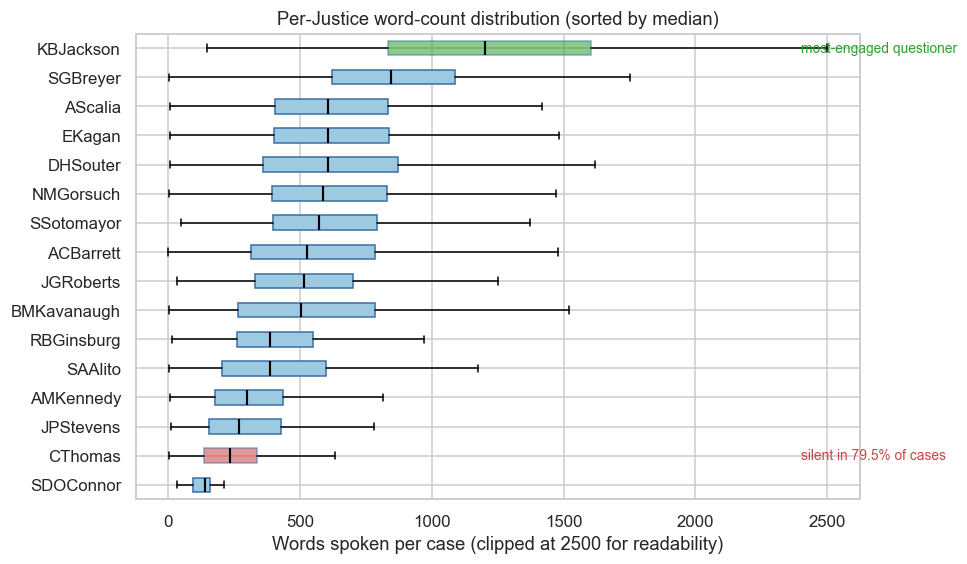

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
order = wc_summary.index.tolist()
data_by = [labeled[labeled['justiceName'] == j]['word_count'].clip(upper=2500).values for j in order]
bp = ax.boxplot(data_by, vert=False, labels=order, showfliers=False, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.4))
for patch in bp['boxes']:
    patch.set_facecolor('#9ecae1')
    patch.set_edgecolor('#3a6ea5')
highlight = {'CThomas': '#c44', 'KBJackson': '#2ca02c'}
for i, j in enumerate(order):
    if j in highlight:
        bp['boxes'][i].set_facecolor(highlight[j])
        bp['boxes'][i].set_alpha(0.55)
ax.set_xlabel('Words spoken per case (clipped at 2500 for readability)')
ax.set_title('Per-Justice word-count distribution (sorted by median)')
ax.text(2400, order.index('CThomas') + 1, 'silent in 79.5% of cases',
        va='center', color='#c44', fontsize=9)
ax.text(2400, order.index('KBJackson') + 1, 'most-engaged questioner',
        va='center', color='#2ca02c', fontsize=9)
plt.show()

## 3. Cases per term & petitioner-win rate over time

Coverage by term (after Oyez fetch + parse) and the empirical petitioner-win rate per term. The win rate is remarkably stable — small year-to-year variation, no obvious trend, which means the class imbalance isn't an artifact of one unusual term.

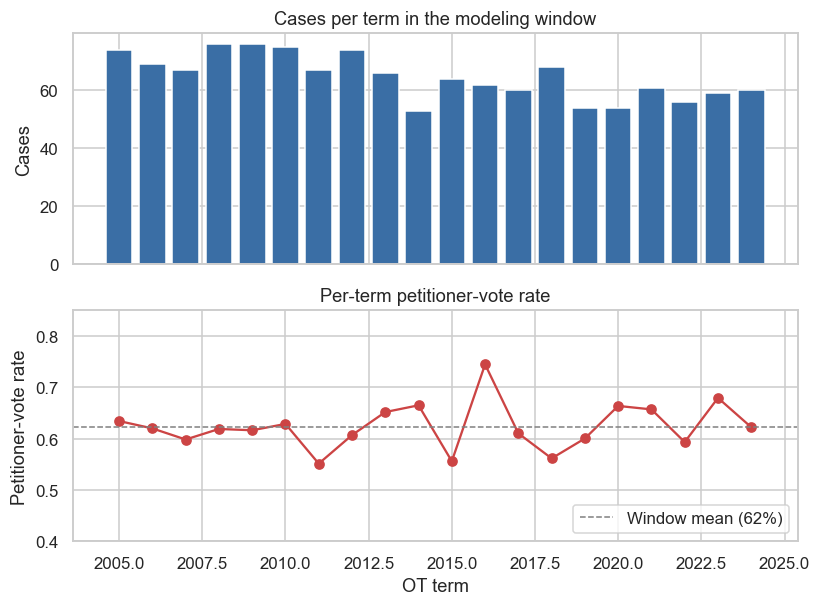

In [5]:
by_term = labeled.groupby('term').agg(
    n_rows=('voted_petitioner', 'size'),
    n_cases=('caseId', 'nunique'),
    pet_win_rate=('voted_petitioner', 'mean'),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(8.5, 6), sharex=True)
axes[0].bar(by_term['term'], by_term['n_cases'], color='#3a6ea5')
axes[0].set_ylabel('Cases')
axes[0].set_title('Cases per term in the modeling window')
axes[1].plot(by_term['term'], by_term['pet_win_rate'], marker='o', color='#c44', linewidth=1.5)
axes[1].axhline(labeled['voted_petitioner'].mean(), color='gray', linestyle='--', linewidth=1,
                label=f'Window mean ({labeled["voted_petitioner"].mean():.0%})')
axes[1].set_ylabel('Petitioner-vote rate')
axes[1].set_xlabel('OT term')
axes[1].set_ylim(0.4, 0.85)
axes[1].legend(loc='lower right')
axes[1].set_title('Per-term petitioner-vote rate')
plt.show()

## 4. Unanimous vs contested — label balance and case counts

Unanimous cases (`minVotes == 0`) are kept in the dataset (Non-Negotiable resolution from Phase 1) but flagged via the `unanimous` metadata column. Phase 5 will report metrics split on this flag.

If the model only succeeds on unanimous cases, that's a weak result (the prediction is mostly recovering '9-0' as a structural fact). If it succeeds on contested cases too, the bench-questioning signal is real.

Rows split by unanimity:
                 n_rows  pet_win_rate  n_rows_pct
unanimous                                        
contested          5873      0.570918    0.579363
unanimous (9-0)    4264      0.695591    0.420637


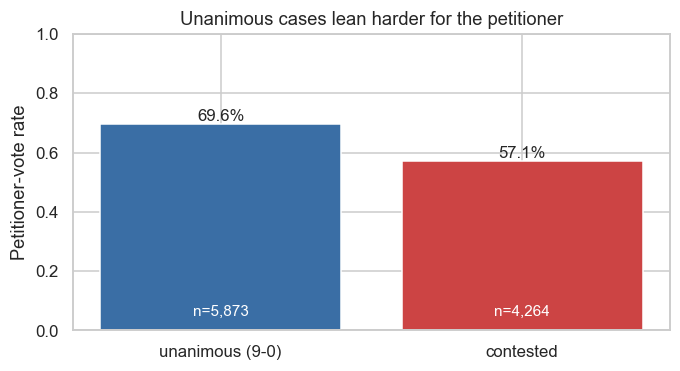

In [6]:
split = labeled.groupby('unanimous').agg(
    n_rows=('voted_petitioner', 'size'),
    pet_win_rate=('voted_petitioner', 'mean'),
)
split.index = split.index.map({1: 'unanimous (9-0)', 0: 'contested'})
split['n_rows_pct'] = split['n_rows'] / split['n_rows'].sum()
print('Rows split by unanimity:')
print(split.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ['unanimous (9-0)', 'contested']
rates = [split.loc[label, 'pet_win_rate'] for label in labels]
bars = ax.bar(labels, rates, color=['#3a6ea5', '#c44'])
for bar, rate, n in zip(bars, rates, split['n_rows']):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.01, f'{rate:.1%}',
            ha='center', fontsize=11)
    ax.text(bar.get_x() + bar.get_width() / 2, 0.05, f'n={n:,}',
            ha='center', color='white', fontsize=10)
ax.set_ylabel('Petitioner-vote rate')
ax.set_ylim(0, 1)
ax.set_title('Unanimous cases lean harder for the petitioner')
plt.show()

## 5. Talkativeness vs predictability — preview

Naïve preview: for each Justice, plot `median word_count` against `predictability` measured as `max(petitioner-win-rate, 1 - petitioner-win-rate)` — i.e., how well the majority-class baseline predicts that Justice in particular.

This is _not_ model performance — it's a structural sanity check. Phase 5 will replace this with actual model AUC per Justice.

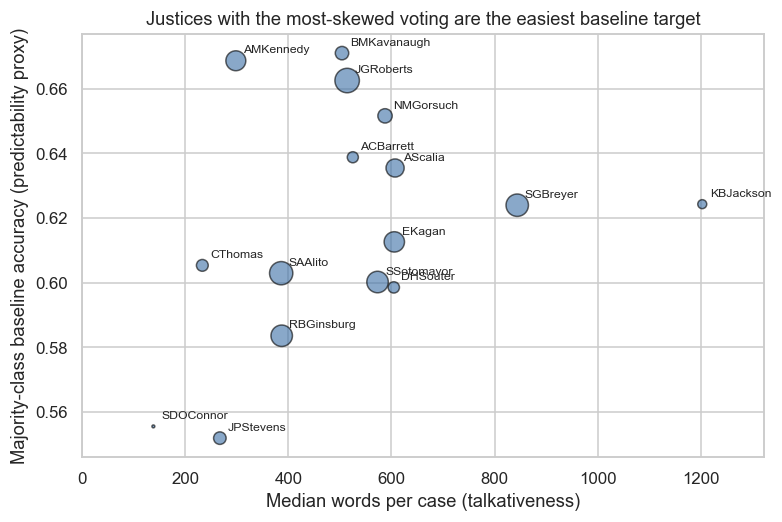

In [7]:
per_just = labeled.groupby('justiceName').agg(
    n=('voted_petitioner', 'size'),
    median_wc=('word_count', 'median'),
    pet_rate=('voted_petitioner', 'mean'),
).reset_index()
per_just['baseline_acc'] = per_just['pet_rate'].apply(lambda p: max(p, 1 - p))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(per_just['median_wc'], per_just['baseline_acc'],
           s=per_just['n'] / 5, alpha=0.6, color='#3a6ea5', edgecolor='black')
for _, r in per_just.iterrows():
    ax.annotate(r['justiceName'], (r['median_wc'], r['baseline_acc']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)
ax.set_xlabel('Median words per case (talkativeness)')
ax.set_ylabel('Majority-class baseline accuracy (predictability proxy)')
ax.set_title('Justices with the most-skewed voting are the easiest baseline target')
ax.set_xlim(0, per_just['median_wc'].max() * 1.1)
plt.show()

## 6. Cleanup decisions for the modeling table

Decisions made in Phase 2 cleanup (codified in `src/build_modeling_table.py`):

1. **Drop NaN-label rows** — `partyWinning ∈ {2, NaN}` (24 rows, unclear winner) or `majority NaN` (147 rows, did not participate). Includes the 45 OT2015 (mostly post-Scalia-death) rows with no SCDB join.
2. **Drop original-jurisdiction cases** — state-vs-state disputes (`* ORIG`, `22O*`, `*, Orig.` patterns). Substantively different (no cert grant, direct filing) and Oyez doesn't catalog them under SCDB-style dockets anyway. ~17 rows.
3. **Drop rows with `word_count < 30`** — empirically chosen from the distribution. Below 30 words almost everything is a truncated half-utterance (`'What --'`, `'Counsel --'`) with no stance signal. ~81 rows.
4. **Keep unanimous cases** — flagged via `unanimous`, split-analyzed in Phase 5.
5. **Keep Thomas** — 302 cases is enough for stable per-Justice estimates with a low-n caveat in Phase 5.

In [8]:
import io
audit = pd.read_csv(ROOT / 'reports/results/modeling_table_audit.csv')
print('Cleanup audit (per-stage row counts):')
print(audit.to_string(index=False))
print()
print(f'Final modeling-table rows: {len(model):,}')
print(f'Distinct cases:            {model["caseId"].nunique():,}')
print(f'Petitioner-win rate:       {(model["voted_petitioner"] == 1).mean():.1%}')
print(f'Unanimous-case rows:       {(model["unanimous"] == 1).sum():,} ({(model["unanimous"] == 1).mean():.1%})')
print(f'Distinct Justices in table: {model["oyez_identifier"].nunique()}')

Cleanup audit (per-stage row counts):
                                 stage  rows_in  rows_out  rows_dropped
     input (justice_case_rows.parquet)    10308     10308             0
             after drop NaN-label rows    10308     10137           171
after drop original-jurisdiction cases    10137     10120            17
            after drop word_count < 30    10120     10039            81

Final modeling-table rows: 10,039
Distinct cases:            1,293
Petitioner-win rate:       62.4%
Unanimous-case rows:       4,207 (41.9%)
Distinct Justices in table: 16


## 7. Storytelling hooks for Phase 5 / 7

From the EDA, the headline angles are:

1. **The Thomas / KBJackson contrast.** Two Justices on the same court with engagement levels an order of magnitude apart. If the model can predict KBJackson well and Thomas poorly (or vice versa) it's a real, publishable storyline for the pitch deck.
2. **Unanimous vs contested.** ~42% of labeled rows are unanimous. The model's "hard" performance lives in the ~58% contested split — that's the number that determines whether this is real prediction or label-prior.
3. **Per-Justice variance in vote skew.** Some Justices vote with petitioner > 80% of the time (an easy baseline); others sit near 50% (genuinely uncertain). Phase 5 must report per-Justice AUC, not just overall accuracy.
4. **Rescued landmark cases.** Citizens United (2009/08-205) was rescued via the term-1 strategy and parses end-to-end with all 8 spoken Justices labeled correctly. It's the natural opener for the pitch deck.